# **Random Forest**

*   A random forest is a supervised machine-learning method for either classification (predicting categories) or regression (predicting numbers).
*   It works by building many decision-trees on different random subsets of the data and features. Each tree gives a prediction, and the forest chooses the majority (for classification) or average (for regression).
*   Building many trees helps reduce over-fitting (compared to a single tree) and improves stability.



In [ ]:
# Load libraries

# Data Processing
import pandas as pd
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

from google.colab import files
upload = files.upload()

Saving bank-additional.csv to bank-additional (6).csv


# **Load the Dataset**

These are the inputs (independent variables)
*   age: The age of the person who received the phone call
*   default: Whether the person has credit in default
*   cons.price.idx: Consumer price index score at the time of the call
*   cons.conf.idx:Consumer confidence index score at the time of the call

the outcome or class you want to predict (dependent variables)
*   y: Whether the person subscribed (this is what we’re trying to predict)







In [ ]:
data = pd.read_csv("bank-additional.csv", sep=';')
print(data.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [ ]:
col_names = ['age', 'default', 'cons.price.idx', 'cons.conf.idx', 'y']
bank_data = pd.read_csv("bank-additional.csv", sep=';', usecols=col_names)
bank_data.head()

,age,default,cons.price.idx,cons.conf.idx,y
0,30,no,92.893,-46.2,no
1,39,no,93.994,-36.4,no
2,25,no,94.465,-41.8,no
3,38,no,94.465,-41.8,no
4,47,no,93.200,-42.0,no


# **The Random Forest Workflow**
To fit and train this model, we’ll be following The Machine Learning Workflow infographic; however, as our data is pretty clean, we won’t be carrying out every step. We will do the following:


*   Feature engineering
*   Split the data
*   Train the model
*   Hyperparameter tuning
*   Assess model performance



# **Preprocessing Data for our Random Forest Classifier**
Tree-based models are much more robust to outliers than linear models, and they do not need variables to be normalized to work. As such, we need to do very little preprocessing on our data.

*   We will map our default column, which contains no and yes, to 0s and 1s, respectively. We will treat unknown values as no for this example.
*   We will also map our target, y, to 1s and 0s.



In [ ]:
bank_data.default.unique()

array(['no', 'unknown', 'yes'], dtype=object)

In [ ]:
bank_data.y.unique()

array(['no', 'yes'], dtype=object)

In [ ]:
# .map({...})
# Replaces each text value with a number, according to the mapping
# you define inside {}.
bank_data['default'] = bank_data['default'].map({'no':0,'yes':1,
                                                'unknown':0})
bank_data['y'] = bank_data['y'].map({'no':0,'yes':1})

# **Splitting the Data**
When training any supervised learning model, it is important to split the data into training and test data. The training data is used to fit the model. The algorithm uses the training data to learn the relationship between the features and the target. The test data is used to evaluate the performance of the model.

The code below splits the data into separate variables for the features and target, then splits into training and test data.

In [ ]:
# Split the data into features (X) and target (y)
# drop('y', axis=1) removes the column named 'y' from the DataFrame.
X = bank_data.drop('y', axis=1)
y = bank_data['y']

# Split the data into training and test sets
# -> stratify=y
# Ensures the class balance (for example, yes/no labels) in both
# training and test sets is the same as in the full dataset.
# This prevents problems if one class is much smaller than the other.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# **Fitting and Evaluating the Random Forest Model**
We first create an instance of the Random forest model with the default parameters. We then fit this to our training data. We pass both the features and the target variable so the model can learn.

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

we have a trained random forest model, but we need to find out whether it makes accurate predictions.

The simplest way to evaluate this model is using accuracy; we check the predictions against the actual values in the test set and count up how many the model got right.

In [ ]:
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ',accuracy)

Accuracy:  0.8944174757281553


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print('Classification Report\n')
print(cr)
print('\nConfusion Matrix\n')
print(cm)

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       734
           1       0.54      0.22      0.31        90

    accuracy                           0.89       824
   macro avg       0.73      0.60      0.63       824
weighted avg       0.87      0.89      0.87       824


Confusion Matrix

[[717  17]
 [ 70  20]]


This is a pretty good score! However, we may be able to do better by optimizing our hyperparameters.

Note: Accuracy alone can be misleading on imbalanced data. Always check precision and recall to understand false-positive and false-negative trade-offs.

# **Visualizing the Results**
We can use the following code to visualize our first 3 trees.

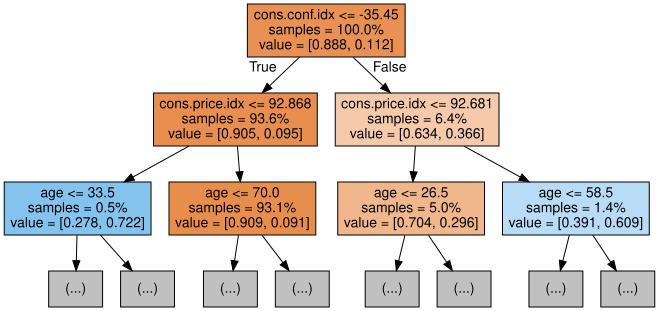

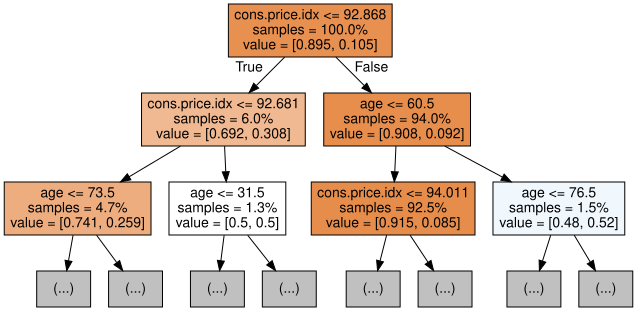

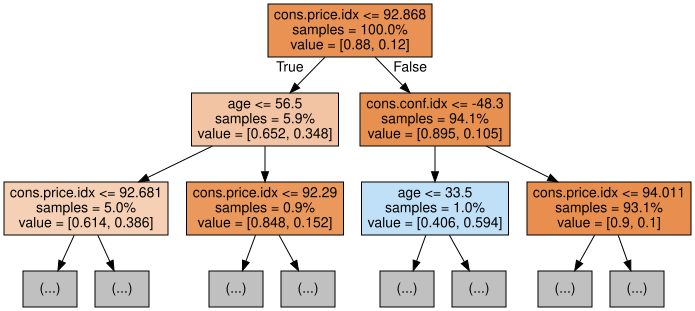

In [ ]:
# Export the first 3 decision tree from the forest

# A random forest contains many individual decision trees stored in
# rf.estimators_.
# This loop selects only the first three trees (i = 0, 1, 2).
for i in range(3):
  # rf.estimators_ is a list of trained DecisionTreeClassifier
  # models inside the forest.
  # This line takes one of those trees and stores it in tree.
  tree = rf.estimators_[i]
  # export_graphviz() converts the decision tree into Graphviz DOT
  # format, which describes how the tree looks (nodes, splits, etc.).
  dot_data = export_graphviz(tree, # # tree: the single decision tree you want to visualize.
                             feature_names=X_train.columns, # feature_names=X_train.columns: names of the features used at each split (so you see real column names, not numbers).
                             filled=True, # filled=True: fills each node with color showing the majority class or class proportion.
                             max_depth=2, # max_depth=2: limits the visualization to only the top 2 levels of the tree so it’s readable.
                             impurity=False, # impurity=False: hides the impurity value (like Gini or entropy) from each node.
                             proportion=True) # proportion=True: shows class proportions instead of raw counts in each node.
  # Converts the DOT data into a Graphviz object so it can be displayed as an image.
  graph = graphviz.Source(dot_data)
  display(graph)

Each tree image is limited to only showing the first few nodes. These trees can get very large and difficult to visualize. The colors represent the majority class of each node (box, with red indicating majority 0 (no subscription) and blue indicating majority 1 (subscription). The colors get darker the closer the node gets to being fully 0 or 1. Each node also contains the following information:

1.   The variable name and value used for splitting
2.   The % of total samples in each split
3.   The % split between classes in each split



# **Hyperparameter Tuning**
The code below uses Scikit-Learn’s RandomizedSearchCV, which will randomly search parameters within a range per hyperparameter. We define the hyperparameters to use and their ranges in the param_dist dictionary. In our case, we are using:


*   n_estimators: the number of decision trees in the forest. Increasing this hyperparameter generally improves the performance of the model but also increases the computational cost of training and predicting.
*   max_depth: the maximum depth of each decision tree in the forest. Setting a higher value for max_depth can lead to overfitting while setting it too low can lead to underfitting.



In [ ]:
# ->This code is used to find the best hyperparameters (settings) for
# your Random Forest model automatically.
# -> Instead of manually trying different parameter values, it
# randomly tests several combinations and chooses the one with the
# best accuracy.
param_dist= {
    # n_estimators Number of trees in the forest
    # randint(a, b) means it will randomly pick integers between a
    # and b (excluding b) each time it runs a trial.
    'n_estimators': randint(100, 500),
    # max_depth Maximum depth of each tree
    # Limits how deep each tree grows; prevents overfitting
    'max_depth': randint(3, 15),
    # min_samples_split Minimum samples required to split a node
    # Higher values make trees simpler
    'min_samples_split': randint(2, 10),
    # min_samples_leaf Minimum samples required in a leaf node
    # Controls how small the final leaves can be
    'min_samples_leaf': randint(1, 5)
}

# Create a random forest classifier
# n_jobs=-1 makes it use all CPU cores to speed up training.
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(rf, # The model to optimize
                                   param_distributions=param_dist, # The parameter space to test, Uses our param_dist dictionar
                                   n_iter=10, # Number of random combinations to try, More iterations = better chance to find best parameters
                                   cv=5, # 5-fold cross-validation, Splits training data into 5 parts for more reliable accuracy
                                   scoring='accuracy', # Metric used to compare results,Uses classification accuracy
                                   n_jobs=-1, # Use all CPU cores, to speed up the search
                                   random_state=42)

In [ ]:
# Fit to traning data
rand_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78349ace85c0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78349a79c950>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78349a79ea80>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78349ab0a000>},
                   random_state=42, scoring='accuracy')

RandomizedSearchCV will train many models (defined by n_iter_ and save each one as variables, the code below creates a variable for the best model and prints the hyperparameters. In this case, we haven’t passed a scoring system to the function, so it defaults to accuracy. This function also uses cross validation, which means it splits the data into five equal-sized groups and uses 4 to train and 1 to test the result. It will loop through each group and give an accuracy score, which is averaged to find the best model.

In [ ]:
# Create a variable for the best model
# rand_search.best_estimator_ returns the single model that
# achieved the highest score during cross-validation.
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
# rand_search.best_params_ returns the exact set of hyperparameters
# that gave the best results.
print('Best hyperparameter: ', rand_search.best_params_)

Best hyperparameter:  {'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 269}


# **More Random Forest Evaluation Metrics**
Let’s look at the confusion matrix. This plots what the model predicted against what the correct prediction was. We can use this to understand the tradeoff between false positives (top right) and false negatives (bottom left). We can plot the confusion matrix using this code:

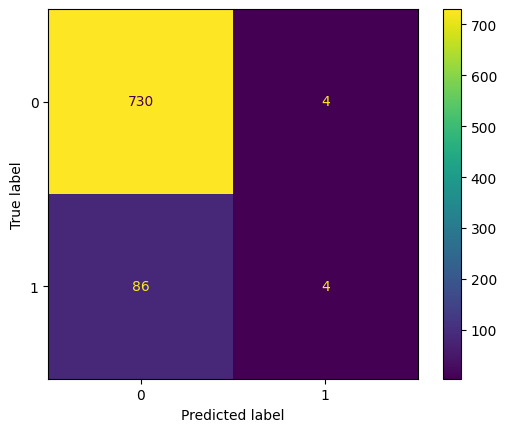

In [ ]:
# Generate prediction with the best model
y_pred = best_rf.predict(X_test)

# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

We should also evaluate the best model with accuracy, precision, and recall (note your results may differ due to randomization)

In [ ]:
# Evaluate the best Random Forest model
y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall )

Accuracy:  0.8907766990291263
Precision:  0.5
Recall:  0.044444444444444446


The below code plots the importance of each feature, using the model’s internal score to find the best way to split the data within each decision tree.

<Axes: >

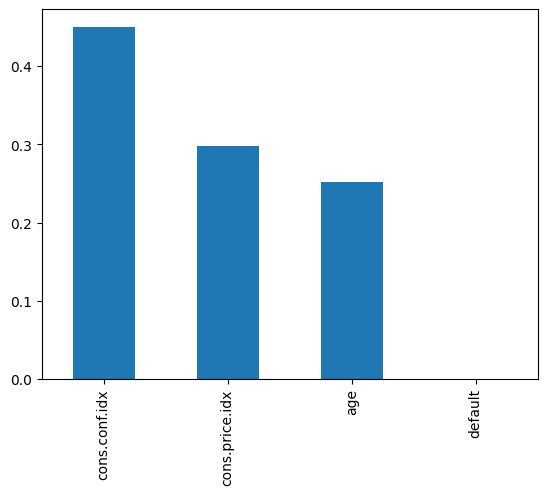

In [ ]:
# Create a series containing feature importances from the model and
# feature names from the training data
# -> feature_importances_.
# It gives an array of numbers, one value per feature (column),
# showing how important that feature was in making predictions.
# -> Higher values mean the feature contributed more to the model’s
# decisions.
importances = pd.Series(best_rf.feature_importances_,
                        index=X_train.columns) # X_train.columns as the index (so each value has its feature name).
importances.sort_values(ascending=False).plot.bar()


# **When to Use Random Forests (and When Not To)**

Use Random Forests when:

*   You have tabular data with mixed feature types
*   You want a robust model without heavy feature scaling or preprocessing
*   Interpretability (via feature importance) matters for your application



However, Random Forests may not be ideal when:



*   You need real-time predictions; they can be slower than single models
*   You’re dealing with very high-dimensional data (e.g., text or images)
*   You want state-of-the-art accuracy on structured data, where gradient boosting methods like XGBoost or LightGBM often outperform them

